# What's the best way to shuffle cards?

The purpose of this notebook is to explore and evaluate the different ways of shuffling cards. The goal is therefore to ensure that a deck of cards is "random" after a minimum number of shuffles, meaning that a player should not be able to predict with certainty the result of the next draw. 

To do this, we use Shannon entropy, which measures the uncertainty associated with an event. Thus, the higher the Shannon entropy, the more information will be needed to accurately determine the next

### 1) The Card and Deck objects

First and foremost, let's define the objects of the study

In [1]:
from dataclasses import dataclass
from enum import Enum

# Special class for the suit of the card
class Suit(Enum):
    HEARTS = "♥"
    CLUBS = "♣"
    DIAMONDS = "♦"
    SPADES = "♠"

# Frozen = True : impossible to modify a card once it is created
# Order= True : give an automatic comparison method
@dataclass(frozen=True, order=True)
class Card:

    # attributes of the card
    value: int  # 1=Ace, 2-10, 11=Jack, 12=Queen, 13=King
    suit: Suit

    # When defined, the value must be in the range [1,13]
    def __post_init__(self):
        if not 1 <= self.value <= 13:
            raise ValueError(f"Invalid value : {self.value} (must be between 1 and 13)")

    def __repr__(self):
        names = {1: "A", 11: "J", 12: "Q", 13: "K"}
        label = names.get(self.value, str(self.value))
        return f"{label}{self.suit.value}"

In [2]:
c1 = Card(1, Suit.SPADES)
c2 = Card(13, Suit.HEARTS)
print(c1, c2)
print(c1 < c2)

A♠ K♥
True


In [3]:
suit_colors = {
        Suit.HEARTS:   "#e34948",
        Suit.CLUBS:    "#2c2c2a",
        Suit.DIAMONDS: "#e34948",
        Suit.SPADES:   "#2c2c2a",
    }
    
suit_symbols = {
        Suit.HEARTS:   "♥",
        Suit.CLUBS:    "♣",
        Suit.DIAMONDS: "♦",
        Suit.SPADES:   "♠",
    }

value_labels = {1: "A", 11: "J", 12: "Q", 13: "K"}

In [4]:
from dataclasses import dataclass, field

# Class Deck
@dataclass
class Deck:
    cards: list[Card] = field(default_factory=list)

    # Initialisation of the deck during the creation of the instance
    def __post_init__(self):
        if not self.cards:
            self.cards = self._new_deck_order()

    # Method to initialise the deck as Aces, 2, 3, 4 ... J, Q, K
    @staticmethod
    def _new_deck_order() -> list[Card]:
        """Standard order of a new deck : by suit, Ace to King."""
        suit_order = [Suit.HEARTS, Suit.CLUBS, Suit.DIAMONDS, Suit.SPADES]
        return [Card(value, suit) for suit in suit_order for value in range(1, 14)]

    # len = 52
    def __len__(self) -> int:
        return len(self.cards)

    # deck[i] return the i-th card
    def __getitem__(self, index):
        return self.cards[index]

    # If we want to use a for loop
    def __iter__(self):
        return iter(self.cards)

    def __repr__(self) -> str:
        return f"Deck({len(self.cards)} cards, top card: {self.cards[0] if self.cards else None})"

    def reset(self) -> None:
        """Reset the deck to its initial order"""
        self.cards = self._new_deck_order()

    def copy(self) -> "Deck":
        """Return an independant copy of the deck"""
        return Deck(cards=self.cards.copy())

In [5]:
d = Deck()
print(d)
print(d[0], d[-1])  # first card, last card

Deck(52 cards, top card: A♥)
A♥ K♠


## 2) Evaluation of the shuffling method of a deck
For each card $c$, after shuffling $N$ times (starting from the same sorted deck), we examine the empirical distribution of its final position: $p_c(j) =$ the probability that card $c$ ends up in position $j$. If the shuffling has almost no effect, $p_c$​ is concentrated around its original position (low entropy, close to $0$).
If the shuffling is perfectly random (ideal Fisher-Yates), $p_c$​ becomes uniformly distributed across the $52$ positions (maximum entropy $= \log_2(52) \approx 5.7$ bits per card).

In [6]:
import numpy as np
from collections import Counter


def position_entropy(decks: list[Deck], reference: Deck) -> float:
    """
    Compute the mean entropy per card, over the entire shuffled deck, 
    compared to the non-shuffled deck.

    Return the mean entropy in bits (0 = aucun mélange, log2(n) = perfectly random).

    decks: list of deck to evaluate shuffled the same way
    reference: the non-shuffled deck
    """

    # Number of cards
    n = len(reference)
    # Number of decks to evaluate
    N = len(decks)

    # Initial position of each card
    ref_position = {card: i for i, card in enumerate(reference.cards)}

    # For each card, we accumulate the empirical distribution of its final position
    # Counter allows to keep in memory the occurence of the card position 
    # (as a dictionary key: position, value: number of times it was observed)
    position_counts = {card: Counter() for card in reference.cards}

    # For each deck, we evaluate the position of the card
    for deck in decks:
        for position, card in enumerate(deck.cards):
            # +1 to the counter of position for this card
            position_counts[card][position] += 1

    entropies = []
    # Conversion of the position to a probability of event
    # For each card of the deck (count = dictionnary containing the position counts)
    for card, counts in position_counts.items():
        # counts.values() = number of times that this position was observed (at least 1 time)
        # / N , to transform it into a probability
        probs = np.array(list(counts.values())) / N
        # h(p) = - p * ln(p)
        h = -np.sum(probs * np.log2(probs))
        # Then the entropy for this card is added
        entropies.append(h)

    # And we return the mean entropy on all the cards
    return float(np.mean(entropies))

In [7]:
# Reference deck
reference = Deck()

# Shuffled deck (the same for the moment)
test = reference.copy()

# Creation of a list of deck shuffled the same way
shuffled_decks = [test for _ in range(20)]

# Evaluation of the entropy
h = position_entropy(shuffled_decks, reference)

# For the moment, H = 0 because it is the same deck
print(f"Mean Entropy : {h:.2f} bits (theorical max : {np.log2(52):.2f})")

Mean Entropy : 0.00 bits (theorical max : 5.70)


## 3) Visualisation of the state of a deck

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_deck(deck: Deck, title: str = "State of the deck") -> None:
    """
    Visualisation of the state of the deck as an histogram
    Each bar represents a card and its position in the deck (position 0 to 51),
    its high represents its value (1=Ace to 13=King).
    """

    fig, ax = plt.subplots(figsize=(14, 5))
    # Color of the background
    fig.patch.set_facecolor("#f1efe8")
    ax.set_facecolor("#f1efe8")


    for position, card in enumerate(deck.cards):

        color = suit_colors[card.suit]
        symbol = suit_symbols[card.suit]
        label = value_labels.get(card.value, str(card.value))

        # bars
        ax.bar(position, card.value, color=color, width=0.75,
               alpha=0.85, linewidth=0)

        # text : value + symbol at the top of the bar
        ax.text(
            position, card.value + 0.2, f"{label}{symbol}",
            ha="center", va="bottom",
            fontsize=6.5, color=color, fontweight="bold",
            rotation=90,
        )

    ax.set_xlim(-0.8, 52)
    ax.set_ylim(0, 17)
    ax.set_xlabel("Position in the deck", fontsize=10, color="#5f5e5a")
    ax.set_ylabel("Value of the card", fontsize=10, color="#5f5e5a")
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])
    ax.set_yticklabels(
        ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"],
        fontsize=8, 
        color="#5f5e5a",)
    
    ax.tick_params(axis="x", labelsize=7, colors="#888780")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_edgecolor("#d3d1c7")
    ax.set_title(title, fontsize=13, fontweight="400",
                 color="#2c2c2a", pad=12)

    # legend colors
    legend_handles = [
        mpatches.Patch(color=suit_colors[suit], label=suit_symbols[suit], alpha=0.85)
        for suit in Suit
    ]
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0,
              loc="upper right", ncol=4)

    plt.tight_layout()
    plt.show()

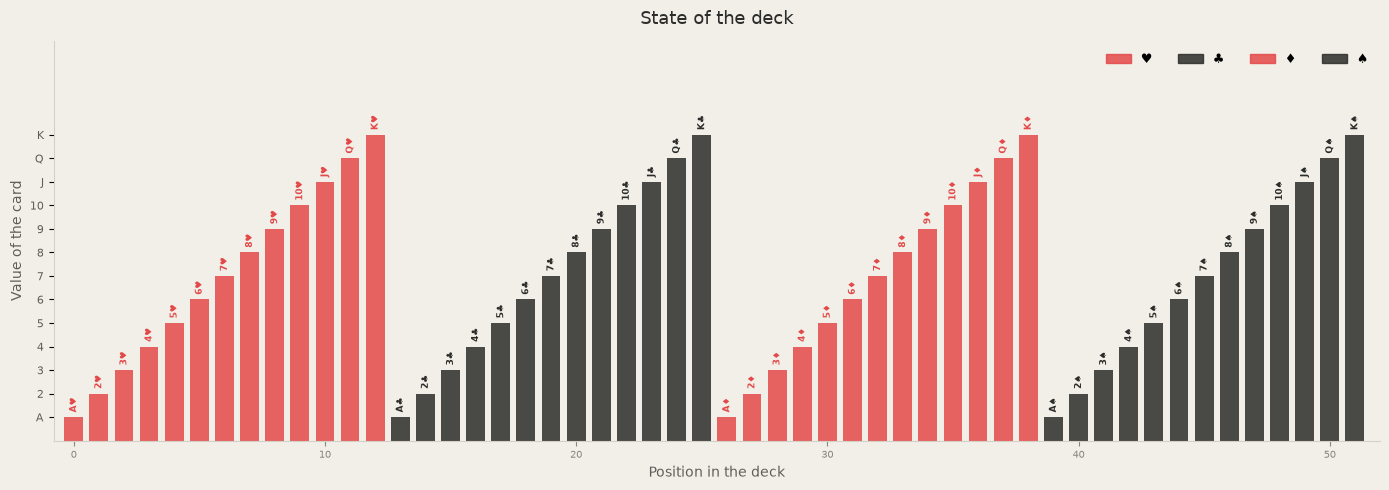

In [9]:
deck = Deck()
plot_deck(deck)

## 4) Different way to shuffle a deck

- Overhand shuffle: A small part of the top deck is put aside, then another top part of the remaining part  of the deck is put on the top of the put-appart part, etc... and the new configuration of the deck is created.
-  My shuffle: I take a random amount of card in the middle of the deck, then put a random part of those cards in the top, then bottom, top, bottom etc... until no card left.
- Riffle shuffle: Also named the "look at me" shuffle, known for bending in an irreversible way the cards, it consists to splitting the deck into 2 parts, and recombining the deck as a sequence of a card of each part one over another.
- Fisher-Yates shuffle: It permutes the last card of the deck with a random card of the rest of the deck, then the process is repeatd with the second-to-last card (the last card is ignored for the random draw). So for a deck of $n$ card, there are $n$ steps.

### Overhand shuffle

In [10]:
import random

def overhand_shuffle(deck: Deck, n_passes: int = 1, inplace: bool = False) -> Deck:
    """
    Overhand shuffle : at each pass, small packets are taken from the top
    and dropped one by one to build a new pile, reversing their order.
    The packet size follows a geometric distribution (parameter p).

    Deck: The deck to shuffle.
    n_passes: The number of passes to perform.
    inplace: Whether to modify the original deck.

    Returns:
        The shuffled deck.
    """
    # Probability of stopping the packet at each card → mean size ~1/p ≈ 7 cards
    p = 0.15

    # Working copy of the cards (we never modify the original deck)
    cards = deck.cards.copy()

    for _ in range(n_passes):

        result = []

        # remaining holds the cards not yet redistributed in this pass
        remaining = cards.copy()

        while remaining:

            # Draw a packet size from a geometric distribution:
            # we keep adding cards (size += 1) as long as random() > p,
            # meaning each card has probability p to be the last of the packet.
            # size starts at 0 but is guaranteed to reach at least 1
            size = 0
            while size == 0 or (size < len(remaining) and random.random() > p):
                size += 1

            # Split the top of the remaining pile into a packet
            packet    = remaining[:size]   # ← taken from the top
            remaining = remaining[size:]   # ← what is left underneath

            # Prepend the packet on top of the result pile
            # (last packet drawn ends up on top, as in a real overhand shuffle)
            result = packet + result

        # The result of this pass becomes the input of the next one
        cards = result

        if inplace:
            deck.cards = cards

    return Deck(cards=cards)

In [11]:
deck = Deck()

overhand_shuffle(deck, n_passes=1, inplace=True)

Deck(52 cards, top card: Q♠)

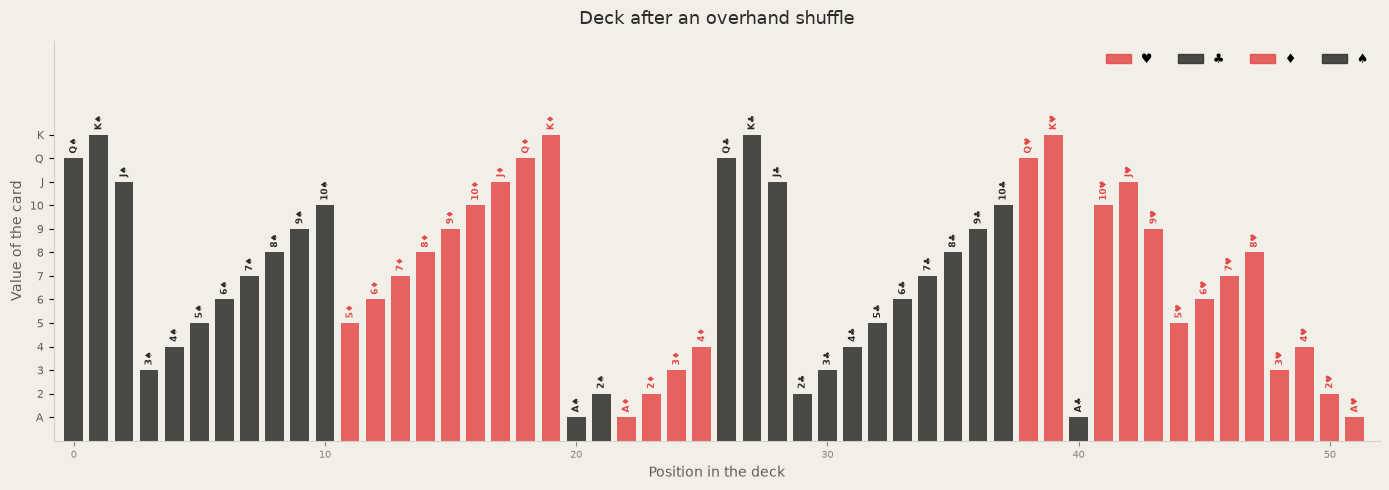

In [12]:
plot_deck(deck, title="Deck after an overhand shuffle")

In [13]:
entropy = position_entropy([overhand_shuffle(deck, n_passes=10, inplace=True) for _ in range(100)], reference=Deck())

print(f"Mean Entropy : {entropy:.2f} bits (theorical max : {np.log2(52):.2f})")

Mean Entropy : 5.29 bits (theorical max : 5.70)


### My shuffle

I also want to know if my method (derived from the Hindu shuffle) used from soooo many years is good, so let's see :)

In [14]:
def my_shuffle(deck: Deck, n_passes: int = 1, inplace=False) -> Deck:
    """
    Custom shuffle :
    1. Extract a contiguous block of random size from the middle of the deck
    2. Redistribute that block alternately to the top and bottom of the
       remaining deck, in random-sized sub-packets, until no cards are left.
    """
    # Working copy of the cards (we never modify the original deck)
    cards = deck.cards.copy()
    n = len(cards)

    for _ in range(n_passes):

        # 1. Choose a contiguous block in the middle :
        #    - start is picked in the first half of the deck
        #    - end is picked after start, in the second half
        start = random.randint(1, n // 2)
        end   = random.randint(n // 2, n - 1)

        # Split the deck into three parts
        top_part    = cards[:start]         # ← cards above the extracted block
        middle_part = cards[start:end]      # ← extracted block
        bottom_part = cards[end:]           # ← cards below the extracted block

        # The remaining deck is top and bottom parts joined
        remaining_deck = top_part + bottom_part

        # 2. Redistribute the middle block alternately to the top and bottom
        #    of remaining_deck, in random-sized sub-packets
        place_on_top = True   # first sub-packet goes to the top

        while middle_part:

            # Random sub-packet size (at least 1, at most what's left)
            size   = random.randint(1, len(middle_part))
            packet = middle_part[:size]
            middle_part = middle_part[size:]

            if place_on_top:
                remaining_deck = packet + remaining_deck   # ← prepend to top
            else:
                remaining_deck = remaining_deck + packet   # ← append to bottom

            # Alternate between top and bottom
            place_on_top = not place_on_top

        cards = remaining_deck

    if inplace:
        deck.cards = cards

    return Deck(cards=cards)

In [28]:
deck = Deck()

my_shuffle(deck, n_passes=1, inplace=True)

Deck(52 cards, top card: Q♣)

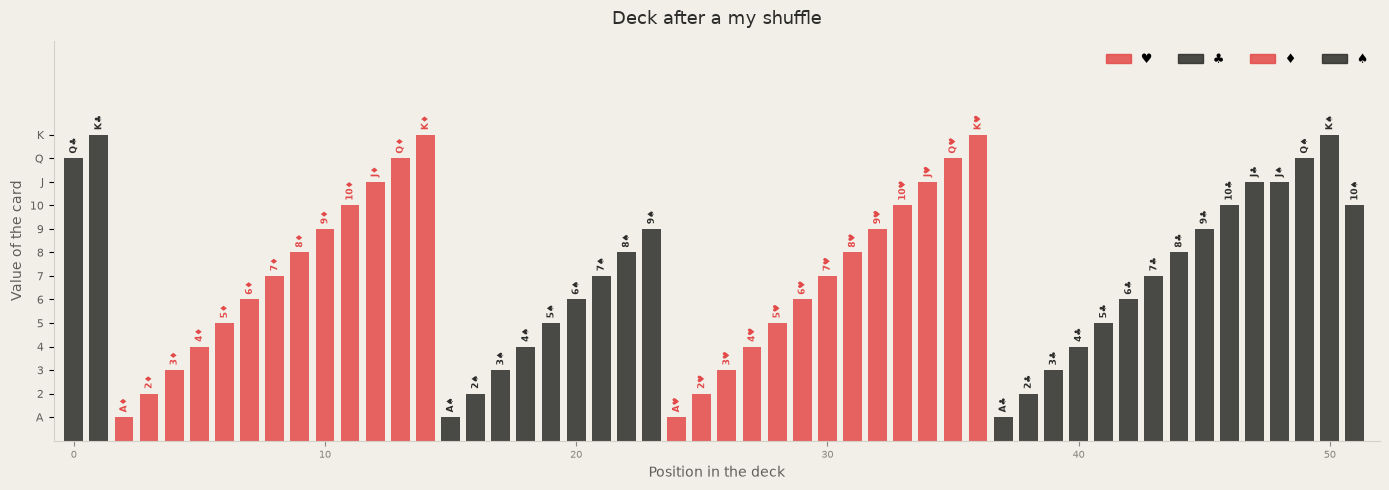

In [29]:
plot_deck(deck, title="Deck after a my shuffle")

### Riffle shuffle

In [17]:
def riffle_shuffle(deck: Deck, n_passes: int = 1, inplace: bool = False) -> Deck:
    """
    Riffle shuffle using the Gilbert-Shannon-Reeds (GSR) model:
    1. Cut the deck into two halves using a binomial distribution B(n, 0.5)
    2. Interleave the two halves proportionally to their remaining sizes.
    """
    # Working copy of the cards (we never modify the original deck)
    cards = deck.cards.copy()
    n = len(cards)

    for _ in range(n_passes):

        # 1. Binomial cut : each card independently goes to the left half
        #    with probability 0.5, so the cut point ~ B(n, 0.5)
        k = sum(random.random() < 0.5 for _ in range(n))
        left  = cards[:k]    # ← first half
        right = cards[k:]    # ← second half

        # 2. GSR interleaving : at each step, the next card is drawn from
        #    the left half with probability len(left) / total remaining,
        #    and from the right half with probability len(right) / total.
        #    This mimics the natural fall of cards from each thumb.
        result = []
        while left or right:

            # If one half is exhausted, append the other directly
            if not left:
                result.extend(right)
                break
            if not right:
                result.extend(left)
                break

            total = len(left) + len(right)

            # Draw from the left half with probability proportional to its size
            if random.random() < len(left) / total:
                result.append(left.pop(0))
            else:
                result.append(right.pop(0))

        cards = result

    if inplace:
        deck.cards = cards

    return Deck(cards=cards)

In [18]:
deck = Deck()

riffle_shuffle(deck, n_passes=1, inplace=True)

Deck(52 cards, top card: A♥)

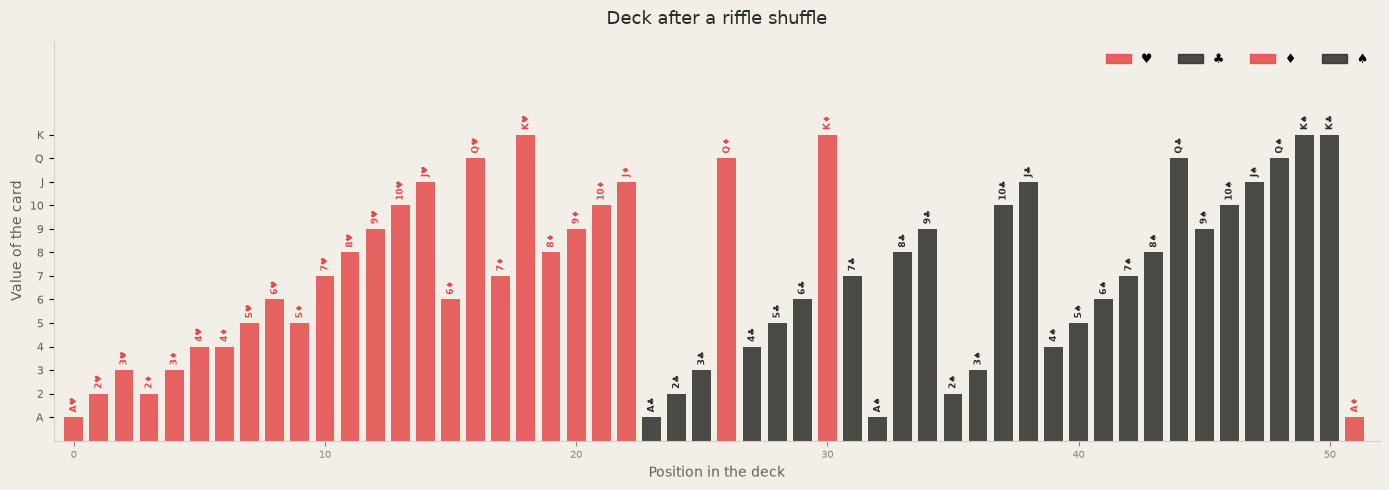

In [19]:
plot_deck(deck, title="Deck after a riffle shuffle")

### Fisher-Yates shuffle

No need to add a `n_riffles` variable, because this shuffle directly produces a distribution of cards in the deck to be unpredictable.

In [20]:
def fisher_yates_shuffle(deck: Deck, inplace=False) -> Deck:
    """
    Fisher-Yates shuffle : produces a perfectly uniform random permutation
    in O(n) time. Each card is swapped with a randomly chosen card among
    those not yet fixed, scanning from the end to the beginning.
    This is the algorithmic reference : maximum entropy in a single pass.
    """
    # Working copy of the cards (we never modify the original deck)
    cards = deck.cards.copy()

    # Scan from the last position down to the second one
    for i in range(len(cards) - 1, 0, -1):

        # Pick a random index j in [0, i] (inclusive)
        j = random.randint(0, i)

        # Swap cards at positions i and j
        cards[i], cards[j] = cards[j], cards[i]

    if inplace:
        deck.cards = cards

    return Deck(cards=cards)

In [21]:
deck = Deck()

fisher_yates_shuffle(deck, inplace=True)

Deck(52 cards, top card: 8♦)

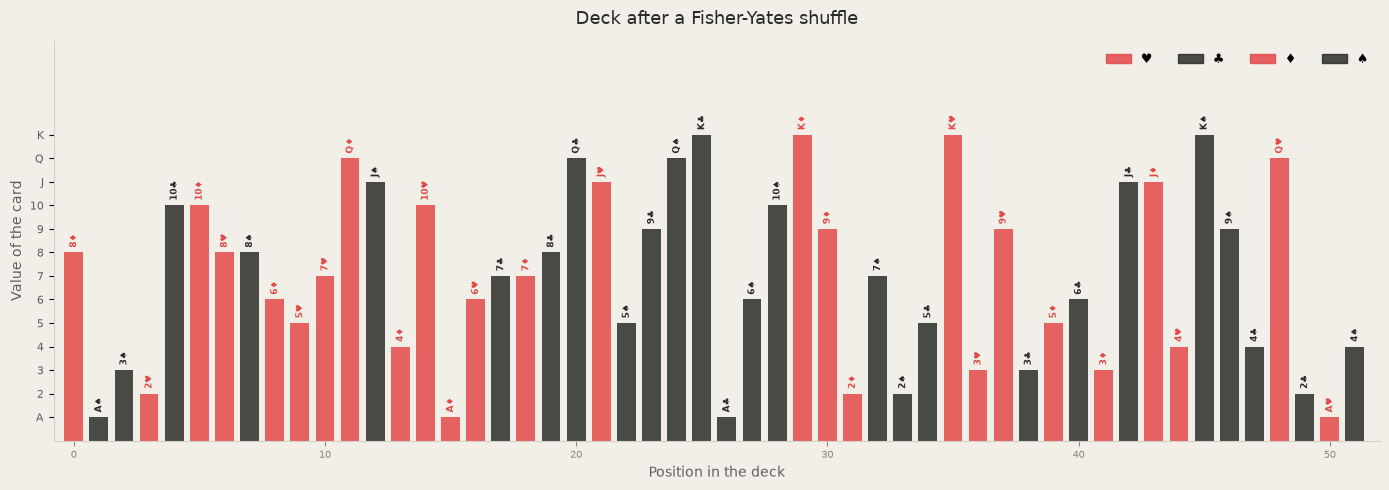

In [22]:
plot_deck(deck, title="Deck after a Fisher-Yates shuffle")

## 5) Comparison of different shuffling methods

In [23]:
max_passes = 10
passes = [i for i in range(1, max_passes + 1)]

# Dictionary to store the mean entropy for each shuffle method and number of passes
entropys = {"overhand_shuffle": [], 
            "my_shuffle": [], 
            "riffle_shuffle": [], 
            "fisher_yates_shuffle": []}

# Number of decks to evaluate for each shuffle method (and do the mean entropy)
N = 10000

for n_passes in passes:
    # Overhand shuffle
    decks = [overhand_shuffle(Deck(), n_passes=n_passes, inplace=False) for _ in range(N)]
    h = position_entropy(decks, reference=Deck())
    entropys["overhand_shuffle"].append(h)

    # My shuffle
    decks = [my_shuffle(Deck(), n_passes=n_passes, inplace=False) for _ in range(N)]
    h = position_entropy(decks, reference=Deck())
    entropys["my_shuffle"].append(h)

    # Riffle shuffle
    decks = [riffle_shuffle(Deck(), n_passes=n_passes, inplace=False) for _ in range(N)]
    h = position_entropy(decks, reference=Deck())
    entropys["riffle_shuffle"].append(h)

    # Fisher-Yates shuffle
    decks = [fisher_yates_shuffle(Deck(), inplace=False) for _ in range(N)]
    h = position_entropy(decks, reference=Deck())
    entropys["fisher_yates_shuffle"].append(h)

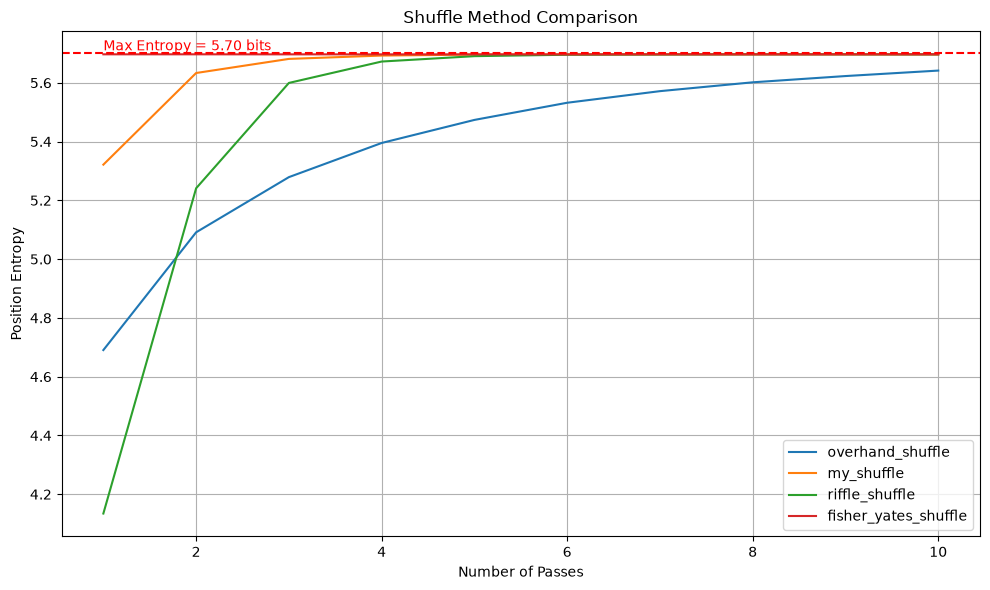

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

dict_colors = {
    "overhand_shuffle": "#1f77b4",  # blue
    "my_shuffle": "#ff7f0e",        # orange
    "riffle_shuffle": "#2ca02c",    # green
    "fisher_yates_shuffle": "#d62728" # red
}

# plot of the entropy for each shuffle method
for method, h_values in entropys.items():
    ax.plot(passes, h_values, label=method, color=dict_colors[method])
    ax.set_xlabel("Number of Passes")
    ax.set_ylabel("Position Entropy")
    ax.set_title("Shuffle Method Comparison")
    ax.legend()
    ax.grid(True)

# Add a horizontal line for the theoretical maximum entropy
max_entropy = np.log2(52)
ax.axhline(y=max_entropy, color='r', linestyle='--', label='Max Entropy')
ax.text(1, max_entropy+0.01, f'Max Entropy = {max_entropy:.2f} bits', color='r')

plt.tight_layout()
plt.show()

## 6) Time required for each shuffle

It seems that my method of shuffling cards is the most effective, but if we also take into account the time it takes to shuffle, is that still the case?

To do this, I timed myself to see how long it takes to perform $N$ actions, and then calculated the average time required for each action (I'm not a croupier but I have a lot of time to waste).

- Overhand shuffle: $183\text{s}$ for $10$ actions $\Rightarrow t_1 = 18.3\text{s}$ per action
- My shuffle: $35\text{s}$ for $10$ actions $\Rightarrow t_2 = 3.5\text{s}$ per action
- Riffle shuffle: $67\text{s}$ for $10$ actions $\Rightarrow t_3 = 6.7\text{s}$ per action
- Fisher-Yates shuffle: $t_4 = 208\text{s}$ per action

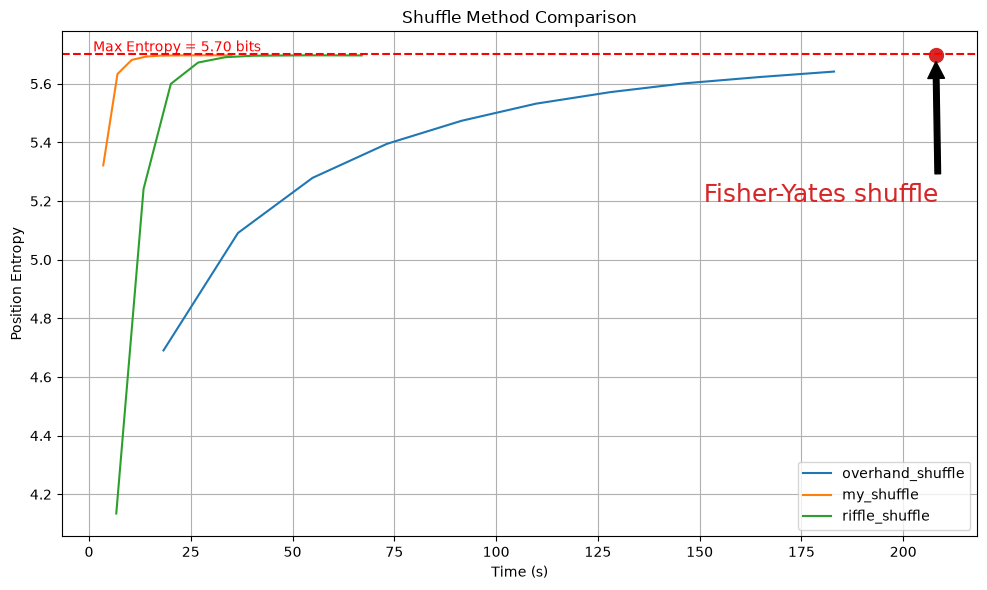

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

times_dict = {"overhand_shuffle": 18.3, 
            "my_shuffle": 3.5, 
            "riffle_shuffle": 6.7, 
            "fisher_yates_shuffle": 208}

for method, time in times_dict.items():
    if method != "fisher_yates_shuffle":
        times_dict[method] = [time * x for x in passes]
    else:
        times_dict[method] = [time]

# plot of the entropy for each shuffle method
for method, h_values in entropys.items():
    if method != "fisher_yates_shuffle":
        ax.plot(times_dict[method], h_values, label=method, color=dict_colors[method])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Position Entropy")
        ax.set_title("Shuffle Method Comparison")
        ax.legend()
        ax.grid(True)

# Add a horizontal line for the theoretical maximum entropy
max_entropy = np.log2(52)
ax.axhline(y=max_entropy, color='r', linestyle='--', label='Max Entropy')
ax.text(1, max_entropy+0.01, f'Max Entropy = {max_entropy:.2f} bits', color='r')

# Add a dot for the Fisher-Yates shuffle
ax.scatter(times_dict["fisher_yates_shuffle"], [entropys["fisher_yates_shuffle"][0]], color=dict_colors["fisher_yates_shuffle"], s=100, label='Fisher-Yates shuffle')
ax.annotate('Fisher-Yates shuffle', 
            xy=(times_dict["fisher_yates_shuffle"][0], 
                entropys["fisher_yates_shuffle"][0]), 
                xytext=(times_dict["fisher_yates_shuffle"][0]-57, entropys["fisher_yates_shuffle"][0]-0.5),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=18, 
                color=dict_colors["fisher_yates_shuffle"])

plt.tight_layout()
plt.show()

## Conclusion

The card-shuffling method I've been using for a long time is very effective, so I'm very relieved that I haven't wasted too much time of my life and that I've thrown a wrench in the plan of cheaters :)